# Chapter 35 — Motion-Aware Tracking with Gap Closing

This notebook consumes the Chapter 34 output:

```text
chapter34_top200_detections.csv
```

It creates motion-aware tracks using:

- physical-coordinate scaling
- constant-velocity prediction
- Hungarian one-to-one assignment
- configurable distance gating
- short-gap closing
- GT node and edge validation
- reusable tracking functions

Primary outputs:

```text
/kaggle/working/chapter35_track_nodes.csv
/kaggle/working/chapter35_track_edges.csv
```

In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 63.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from IPython.display import display

In [3]:
@dataclass(frozen=True)
class TrackingConfig:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    max_link_distance: float = 6.0
    max_gap: int = 2
    rank_penalty_weight: float = 0.35
    pred_dist_penalty_weight: float = 0.15
    velocity_change_penalty_weight: float = 0.25
    node_match_radius: float = 6.0

CONFIG = TrackingConfig()
print(CONFIG)

TrackingConfig(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, max_link_distance=6.0, max_gap=2, rank_penalty_weight=0.35, pred_dist_penalty_weight=0.15, velocity_change_penalty_weight=0.25, node_match_radius=6.0)


## Step 1 — Locate and Load Chapter 34 Detections

In [4]:
def find_file(filename: str) -> Path:
    roots = [
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("."),
    ]

    for root in roots:
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            return direct

    matches = []
    for root in roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Run Chapter 34 first or attach "
        "its output as a Kaggle dataset."
    )


detections_path = find_file(
    "chapter34_top200_detections.csv"
)

detections_df = pd.read_csv(detections_path)

required_columns = [
    "t", "z", "y", "x",
    "rank_position", "pred_dist",
]

missing = [
    column
    for column in required_columns
    if column not in detections_df.columns
]

if missing:
    raise KeyError(
        "Missing Chapter 34 columns: "
        + ", ".join(missing)
    )

if "detection_id" not in detections_df.columns:
    detections_df["detection_id"] = [
        f"detection_{i}"
        for i in range(len(detections_df))
    ]

detections_df = (
    detections_df
    .sort_values(["t", "rank_position"])
    .reset_index(drop=True)
)

print("Loaded:", detections_path)
print("Rows:", len(detections_df))
print("Frames:", detections_df["t"].nunique())
display(detections_df.head())

Loaded: /kaggle/input/datasets/emailchrismathews/chapter34-top200-detections-csv/chapter34_top200_detections.csv
Rows: 20000
Frames: 100


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,41,130,131,4.0,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,...,6.222860,1.625000,1660.5625,294.09106,1.7500,0,7.354238,-7.354238,1,chapter34_t0_0
1,24,123,85,4.0,3,large_sensitive|medium_sensitive|medium_strict,1279.0,1279.0,1216.271606,1353.0,...,7.320772,2.071477,1383.4375,293.54013,1.4375,0,7.437489,-7.437489,2,chapter34_t0_1
2,37,193,95,5.0,1,large_sensitive,1507.0,1507.0,1466.740723,1611.0,...,5.935492,1.723573,1556.0625,249.27237,1.4375,0,7.584010,-7.584010,3,chapter34_t0_2
3,17,255,95,5.0,1,large_sensitive,1195.0,1195.0,1210.688843,1365.0,...,9.283495,2.071477,1226.3125,199.05817,1.5000,0,7.949785,-7.949785,4,chapter34_t0_3
4,25,125,88,3.5,1,medium_sensitive,1192.0,1192.0,1120.629639,1292.0,...,7.531094,1.625000,1371.1875,286.81174,1.5625,0,8.260656,-8.260656,5,chapter34_t0_4


## Step 2 — Add Physical Coordinates

In [5]:
def add_physical_coordinates(
    detections: pd.DataFrame,
    config: TrackingConfig,
) -> pd.DataFrame:
    result = detections.copy()

    result["z_physical"] = (
        result["z"].astype(float)
        * config.z_scale
    )
    result["y_physical"] = (
        result["y"].astype(float)
        * config.y_scale
    )
    result["x_physical"] = (
        result["x"].astype(float)
        * config.x_scale
    )

    return result


detections_df = add_physical_coordinates(
    detections_df,
    CONFIG,
)

display(
    detections_df[
        [
            "t", "detection_id",
            "z", "y", "x",
            "z_physical",
            "y_physical",
            "x_physical",
        ]
    ].head()
)

,t,detection_id,z,y,x,z_physical,y_physical,x_physical
0,0,chapter34_t0_0,41,130,131,66.625,52.81250,53.21875
1,0,chapter34_t0_1,24,123,85,39.000,49.96875,34.53125
2,0,chapter34_t0_2,37,193,95,60.125,78.40625,38.59375
3,0,chapter34_t0_3,17,255,95,27.625,103.59375,38.59375
4,0,chapter34_t0_4,25,125,88,40.625,50.78125,35.75000


## Step 3 — Load GEFF Ground Truth for Validation

The tracker can run without GT. Validation is skipped when the competition input is unavailable.

In [6]:
def load_gt(sample_id: str):
    root = Path(
        "/kaggle/input/competitions/"
        "biohub-cell-tracking-during-development/train"
    )

    geff_path = root / f"{sample_id}.geff"

    if not geff_path.exists():
        print("GT not found. Validation will be skipped.")
        return None, None

    geff = zarr.open(
        geff_path,
        mode="r",
    )

    nodes = pd.DataFrame({
        "gt_node_id": geff["nodes/ids"][:],
        "t": geff["nodes/props/t/values"][:],
        "z": geff["nodes/props/z/values"][:],
        "y": geff["nodes/props/y/values"][:],
        "x": geff["nodes/props/x/values"][:],
    })

    if "edges/ids" not in geff:
        raise KeyError(
            "The GEFF file does not contain edges/ids."
        )

    edge_ids = np.asarray(
        geff["edges/ids"][:]
    )

    if edge_ids.ndim != 2 or edge_ids.shape[1] != 2:
        raise ValueError(
            "Expected edges/ids to have shape (E, 2), "
            f"but received {edge_ids.shape}."
        )

    edges = pd.DataFrame({
        "gt_source": edge_ids[:, 0],
        "gt_target": edge_ids[:, 1],
    })

    return nodes, edges


gt_nodes_df, gt_edges_df = load_gt(
    CONFIG.sample_id
)

if gt_nodes_df is not None:
    print("GT nodes:", len(gt_nodes_df))
    print("GT edges:", len(gt_edges_df))

    display(gt_edges_df.head())

GT nodes: 788
GT edges: 773


,gt_source,gt_target
0,106000000037,107000000037
1,106000000040,107000000040
2,106000000041,107000000041
3,106000000043,107000000043
4,106000000056,107000000056


## Step 4 — Active Track State

In [7]:
@dataclass
class ActiveTrack:
    track_id: int
    detection_ids: list[str]
    timepoints: list[int]
    physical_positions: list[np.ndarray]
    voxel_positions: list[np.ndarray]
    rank_positions: list[int]
    pred_distances: list[float]
    missed_frames: int = 0

    @property
    def last_t(self):
        return int(self.timepoints[-1])

    @property
    def last_position(self):
        return self.physical_positions[-1]

    @property
    def velocity(self):
        if len(self.physical_positions) < 2:
            return np.zeros(3, dtype=np.float32)

        dt = self.timepoints[-1] - self.timepoints[-2]
        if dt <= 0:
            return np.zeros(3, dtype=np.float32)

        return (
            self.physical_positions[-1]
            - self.physical_positions[-2]
        ) / dt

    def predict(self, next_t: int):
        dt = int(next_t) - self.last_t
        return self.last_position + self.velocity * dt

    def append(self, row: pd.Series):
        self.detection_ids.append(
            str(row["detection_id"])
        )
        self.timepoints.append(int(row["t"]))
        self.physical_positions.append(
            row[
                [
                    "z_physical",
                    "y_physical",
                    "x_physical",
                ]
            ].to_numpy(dtype=np.float32)
        )
        self.voxel_positions.append(
            row[["z", "y", "x"]]
            .to_numpy(dtype=np.float32)
        )
        self.rank_positions.append(
            int(row["rank_position"])
        )
        self.pred_distances.append(
            float(row["pred_dist"])
        )
        self.missed_frames = 0

## Step 5 — Hungarian Assignment Cost

In [8]:
def assignment_cost_matrix(
    tracks: list[ActiveTrack],
    detections_t: pd.DataFrame,
    timepoint: int,
    config: TrackingConfig,
) -> np.ndarray:
    if not tracks or detections_t.empty:
        return np.empty(
            (len(tracks), len(detections_t)),
            dtype=np.float32,
        )

    positions = detections_t[
        ["z_physical", "y_physical", "x_physical"]
    ].to_numpy(dtype=np.float32)

    ranks = detections_t[
        "rank_position"
    ].to_numpy(dtype=np.float32)

    pred_dist = detections_t[
        "pred_dist"
    ].to_numpy(dtype=np.float32)

    rank_penalty = ranks / max(float(ranks.max()), 1.0)

    pred_scale = max(
        float(np.nanpercentile(pred_dist, 95)),
        1.0,
    )
    pred_penalty = np.clip(
        np.nan_to_num(pred_dist, nan=pred_scale)
        / pred_scale,
        0.0,
        2.0,
    )

    cost = np.full(
        (len(tracks), len(detections_t)),
        np.inf,
        dtype=np.float32,
    )

    for track_index, track in enumerate(tracks):
        predicted_position = track.predict(timepoint)

        spatial_distance = np.linalg.norm(
            positions - predicted_position,
            axis=1,
        )

        time_gap = timepoint - track.last_t
        allowed_distance = (
            config.max_link_distance
            * max(1, time_gap)
        )

        candidate_velocity = (
            positions - track.last_position
        ) / max(1, time_gap)

        velocity_change = np.linalg.norm(
            candidate_velocity - track.velocity,
            axis=1,
        )

        total = (
            spatial_distance
            + config.rank_penalty_weight * rank_penalty
            + config.pred_dist_penalty_weight * pred_penalty
            + config.velocity_change_penalty_weight
            * velocity_change
        )

        valid = spatial_distance <= allowed_distance
        cost[track_index, valid] = total[valid]

    return cost


def solve_assignments(
    tracks: list[ActiveTrack],
    detections_t: pd.DataFrame,
    timepoint: int,
    config: TrackingConfig,
):
    cost = assignment_cost_matrix(
        tracks,
        detections_t,
        timepoint,
        config,
    )

    if cost.size == 0:
        return []

    rows, columns = linear_sum_assignment(
        np.where(np.isfinite(cost), cost, 1e9)
    )

    assignments = []

    for track_index, detection_index in zip(
        rows,
        columns,
    ):
        value = float(
            cost[track_index, detection_index]
        )

        if np.isfinite(value):
            assignments.append(
                {
                    "track_index": int(track_index),
                    "detection_index": int(detection_index),
                    "cost": value,
                }
            )

    return assignments

## Step 6 — Reusable Tracking Pipeline

In [9]:
def track_sequence(
    detections: pd.DataFrame,
    config: TrackingConfig = CONFIG,
):
    detections = (
        detections
        .sort_values(["t", "rank_position"])
        .reset_index(drop=True)
    )

    active_tracks = []
    finished_tracks = []
    edge_rows = []
    frame_rows = []
    next_track_id = 0

    for timepoint in sorted(detections["t"].unique()):
        detections_t = (
            detections[
                detections["t"] == timepoint
            ]
            .sort_values("rank_position")
            .reset_index(drop=True)
        )

        eligible_tracks = [
            track
            for track in active_tracks
            if (
                int(timepoint) - track.last_t
                <= config.max_gap + 1
            )
        ]

        assignments = solve_assignments(
            eligible_tracks,
            detections_t,
            int(timepoint),
            config,
        )

        matched_track_ids = set()
        matched_detection_indices = set()

        for assignment in assignments:
            track = eligible_tracks[
                assignment["track_index"]
            ]
            row = detections_t.iloc[
                assignment["detection_index"]
            ]

            source_id = track.detection_ids[-1]
            source_t = track.last_t

            track.append(row)

            edge_rows.append({
                "track_id": track.track_id,
                "source_detection_id": source_id,
                "target_detection_id": row["detection_id"],
                "source_t": source_t,
                "target_t": int(timepoint),
                "frame_gap": int(timepoint - source_t),
                "assignment_cost": assignment["cost"],
            })

            matched_track_ids.add(track.track_id)
            matched_detection_indices.add(
                assignment["detection_index"]
            )

        for track in active_tracks:
            if track.track_id not in matched_track_ids:
                track.missed_frames += 1

        new_tracks = 0

        for detection_index, row in detections_t.iterrows():
            if detection_index in matched_detection_indices:
                continue

            physical_position = row[
                [
                    "z_physical",
                    "y_physical",
                    "x_physical",
                ]
            ].to_numpy(dtype=np.float32)

            voxel_position = row[
                ["z", "y", "x"]
            ].to_numpy(dtype=np.float32)

            active_tracks.append(
                ActiveTrack(
                    track_id=next_track_id,
                    detection_ids=[
                        str(row["detection_id"])
                    ],
                    timepoints=[int(timepoint)],
                    physical_positions=[
                        physical_position
                    ],
                    voxel_positions=[
                        voxel_position
                    ],
                    rank_positions=[
                        int(row["rank_position"])
                    ],
                    pred_distances=[
                        float(row["pred_dist"])
                    ],
                )
            )

            next_track_id += 1
            new_tracks += 1

        remaining_active = []

        for track in active_tracks:
            if track.missed_frames > config.max_gap:
                finished_tracks.append(track)
            else:
                remaining_active.append(track)

        active_tracks = remaining_active

        frame_rows.append({
            "t": int(timepoint),
            "num_detections": len(detections_t),
            "num_links": len(assignments),
            "num_new_tracks": new_tracks,
            "num_active_tracks": len(active_tracks),
        })

        print(
            f"t={timepoint}: detections={len(detections_t)}, "
            f"links={len(assignments)}, "
            f"new_tracks={new_tracks}, "
            f"active={len(active_tracks)}"
        )

    finished_tracks.extend(active_tracks)

    node_rows = []

    for track in finished_tracks:
        for index, detection_id in enumerate(
            track.detection_ids
        ):
            voxel = track.voxel_positions[index]
            physical = track.physical_positions[index]

            node_rows.append({
                "track_id": track.track_id,
                "detection_id": detection_id,
                "t": track.timepoints[index],
                "z": float(voxel[0]),
                "y": float(voxel[1]),
                "x": float(voxel[2]),
                "z_physical": float(physical[0]),
                "y_physical": float(physical[1]),
                "x_physical": float(physical[2]),
                "rank_position": track.rank_positions[index],
                "pred_dist": track.pred_distances[index],
            })

    return {
        "track_nodes": pd.DataFrame(node_rows),
        "track_edges": pd.DataFrame(edge_rows),
        "frame_summary": pd.DataFrame(frame_rows),
    }

In [10]:
tracking_results = track_sequence(
    detections_df,
    CONFIG,
)

track_nodes_df = tracking_results["track_nodes"]
track_edges_df = tracking_results["track_edges"]
frame_summary_df = tracking_results["frame_summary"]

print("Track nodes:", len(track_nodes_df))
print("Track edges:", len(track_edges_df))
print("Tracks:", track_nodes_df["track_id"].nunique())

display(track_nodes_df.head())
display(track_edges_df.head())

t=0: detections=200, links=0, new_tracks=200, active=200
t=1: detections=200, links=85, new_tracks=115, active=315
t=2: detections=200, links=139, new_tracks=61, active=376
t=3: detections=200, links=175, new_tracks=25, active=380
t=4: detections=200, links=173, new_tracks=27, active=384
t=5: detections=200, links=177, new_tracks=23, active=382
t=6: detections=200, links=182, new_tracks=18, active=385
t=7: detections=200, links=163, new_tracks=37, active=391
t=8: detections=200, links=154, new_tracks=46, active=412
t=9: detections=200, links=174, new_tracks=26, active=405
t=10: detections=200, links=174, new_tracks=26, active=400
t=11: detections=200, links=176, new_tracks=24, active=385
t=12: detections=200, links=165, new_tracks=35, active=395
t=13: detections=200, links=171, new_tracks=29, active=387
t=14: detections=200, links=161, new_tracks=39, active=395
t=15: detections=200, links=159, new_tracks=41, active=394
t=16: detections=200, links=176, new_tracks=24, active=383
t=17: de

,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist
0,6,chapter34_t0_6,0,41.0,130.0,135.0,66.625,52.81250,54.84375,7,8.838406
1,28,chapter34_t0_28,0,22.0,190.0,59.0,35.750,77.18750,23.96875,29,11.861735
2,32,chapter34_t0_32,0,41.0,121.0,127.0,66.625,49.15625,51.59375,33,12.491119
3,34,chapter34_t0_34,0,38.0,130.0,133.0,61.750,52.81250,54.03125,35,12.895166
4,48,chapter34_t0_48,0,26.0,192.0,62.0,42.250,78.00000,25.18750,49,15.233347


,track_id,source_detection_id,target_detection_id,source_t,target_t,frame_gap,assignment_cost
0,0,chapter34_t0_0,chapter34_t1_66,0,1,1,3.509804
1,2,chapter34_t0_2,chapter34_t1_6,0,1,1,5.884148
2,3,chapter34_t0_3,chapter34_t1_95,0,1,1,1.327969
3,5,chapter34_t0_5,chapter34_t1_1,0,1,1,6.903031
4,7,chapter34_t0_7,chapter34_t1_64,0,1,1,2.989084


## Step 7 — Track Summaries

In [11]:
def summarize_tracks(
    track_nodes: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for track_id, group in track_nodes.groupby("track_id"):
        group = group.sort_values("t")
        points = group[
            [
                "z_physical",
                "y_physical",
                "x_physical",
            ]
        ].to_numpy(dtype=np.float32)

        if len(points) > 1:
            path_length = float(
                np.linalg.norm(
                    np.diff(points, axis=0),
                    axis=1,
                ).sum()
            )
            displacement = float(
                np.linalg.norm(
                    points[-1] - points[0]
                )
            )
        else:
            path_length = 0.0
            displacement = 0.0

        rows.append({
            "track_id": int(track_id),
            "start_t": int(group["t"].min()),
            "end_t": int(group["t"].max()),
            "num_detections": len(group),
            "duration": int(
                group["t"].max()
                - group["t"].min()
                + 1
            ),
            "mean_rank": float(
                group["rank_position"].mean()
            ),
            "mean_pred_dist": float(
                group["pred_dist"].mean()
            ),
            "path_length_physical": path_length,
            "net_displacement_physical": displacement,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "num_detections",
            ascending=False,
        )
        .reset_index(drop=True)
    )


track_summary_df = summarize_tracks(
    track_nodes_df
)

display(track_summary_df.head(30))

,track_id,start_t,end_t,num_detections,duration,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical
0,308,1,60,41,60,78.951220,16.666925,184.684158,79.666443
1,1350,33,80,32,48,100.656250,16.724343,170.022308,45.011326
2,768,15,57,31,43,94.870968,16.746061,115.916397,59.430641
3,760,15,60,31,46,93.612903,16.811276,130.364609,28.992136
4,668,13,56,30,44,73.566667,15.999786,178.607941,57.746120
5,1055,25,72,30,48,95.866667,16.601000,198.085327,69.073250
6,1442,37,92,29,56,109.620690,16.864830,272.921112,71.777603
7,1279,31,72,28,42,87.250000,16.693830,125.934830,68.041718
8,2010,54,99,27,46,92.555556,16.333719,136.121185,46.859840
9,501,7,50,27,44,92.814815,16.847740,135.222900,34.629089


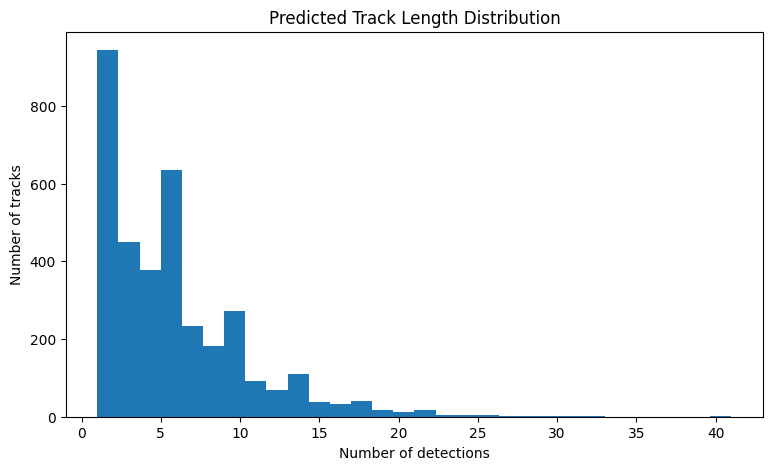

In [12]:
plt.figure(figsize=(9, 5))
plt.hist(
    track_summary_df["num_detections"],
    bins=30,
)
plt.title("Predicted Track Length Distribution")
plt.xlabel("Number of detections")
plt.ylabel("Number of tracks")
plt.show()

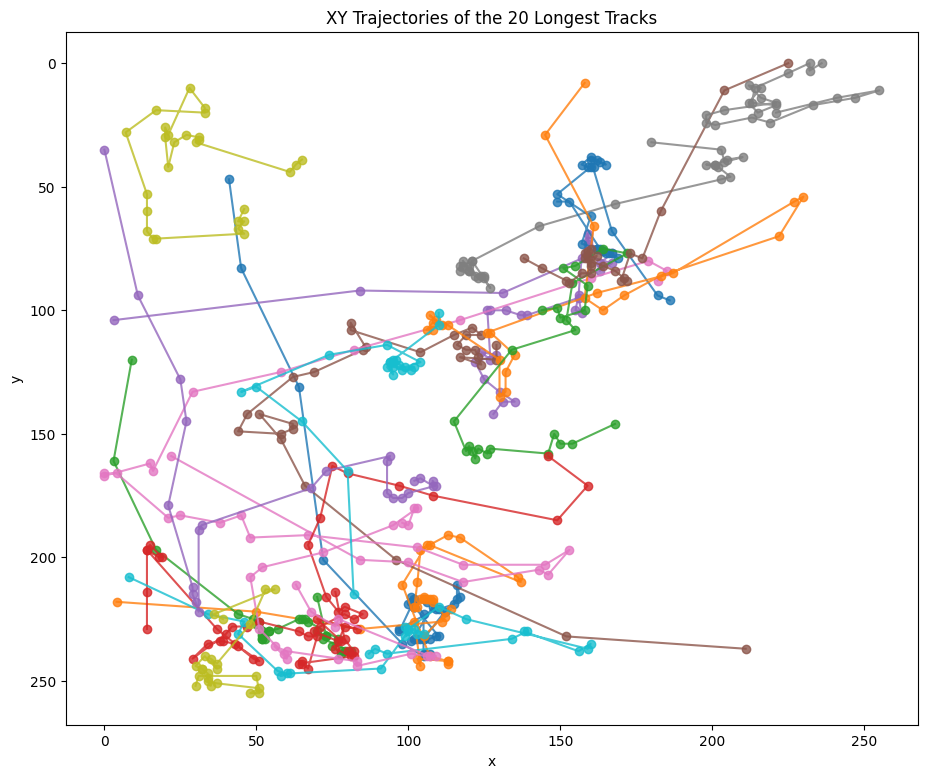

In [13]:
def plot_longest_tracks(
    track_nodes: pd.DataFrame,
    track_summary: pd.DataFrame,
    number_of_tracks: int = 20,
):
    selected_ids = (
        track_summary
        .head(number_of_tracks)["track_id"]
        .to_list()
    )

    plt.figure(figsize=(11, 9))

    for track_id in selected_ids:
        track = (
            track_nodes[
                track_nodes["track_id"] == track_id
            ]
            .sort_values("t")
        )

        plt.plot(
            track["x"],
            track["y"],
            marker="o",
            alpha=0.8,
        )

    plt.gca().invert_yaxis()
    plt.title(
        f"XY Trajectories of the {number_of_tracks} Longest Tracks"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


plot_longest_tracks(
    track_nodes_df,
    track_summary_df,
)

## Step 8 — Match Predicted Nodes to GT

In [14]:
def match_nodes_to_gt(
    track_nodes: pd.DataFrame,
    gt_nodes: pd.DataFrame,
    radius: float,
) -> pd.DataFrame:
    rows = []

    for timepoint in sorted(track_nodes["t"].unique()):
        pred_t = (
            track_nodes[
                track_nodes["t"] == timepoint
            ]
            .reset_index(drop=True)
        )
        gt_t = (
            gt_nodes[
                gt_nodes["t"] == timepoint
            ]
            .reset_index(drop=True)
        )

        if pred_t.empty or gt_t.empty:
            continue

        distance = cdist(
            pred_t[["z", "y", "x"]]
            .to_numpy(dtype=np.float32),
            gt_t[["z", "y", "x"]]
            .to_numpy(dtype=np.float32),
        )

        rows_idx, cols_idx = linear_sum_assignment(
            np.where(distance <= radius, distance, 1e9)
        )

        for pred_index, gt_index in zip(
            rows_idx,
            cols_idx,
        ):
            value = float(
                distance[pred_index, gt_index]
            )

            if value > radius:
                continue

            rows.append({
                "detection_id": pred_t.iloc[
                    pred_index
                ]["detection_id"],
                "track_id": int(
                    pred_t.iloc[pred_index]["track_id"]
                ),
                "t": int(timepoint),
                "gt_node_id": gt_t.iloc[
                    gt_index
                ]["gt_node_id"],
                "match_distance": value,
            })

    return pd.DataFrame(rows)


if gt_nodes_df is not None:
    node_matches_df = match_nodes_to_gt(
        track_nodes_df,
        gt_nodes_df,
        CONFIG.node_match_radius,
    )

    print("Matched nodes:", len(node_matches_df))
    display(node_matches_df.head())
else:
    node_matches_df = pd.DataFrame()

Matched nodes: 362


,detection_id,track_id,t,gt_node_id,match_distance
0,chapter34_t0_17,17,0,1.060000e+11,1.414214
1,chapter34_t0_0,0,0,1.060000e+11,3.316625
2,chapter34_t0_27,27,0,1.060000e+11,2.828427
3,chapter34_t0_21,21,0,1.060000e+11,1.000000
4,chapter34_t0_29,29,0,1.060000e+11,3.741657


## Step 9 — Evaluate Predicted Links

In [15]:
def evaluate_links(
    track_edges: pd.DataFrame,
    node_matches: pd.DataFrame,
    gt_edges: pd.DataFrame,
):
    source_matches = node_matches[
        ["detection_id", "gt_node_id"]
    ].rename(
        columns={
            "detection_id": "source_detection_id",
            "gt_node_id": "matched_gt_source",
        }
    )

    target_matches = node_matches[
        ["detection_id", "gt_node_id"]
    ].rename(
        columns={
            "detection_id": "target_detection_id",
            "gt_node_id": "matched_gt_target",
        }
    )

    evaluated = (
        track_edges
        .merge(
            source_matches,
            on="source_detection_id",
            how="left",
        )
        .merge(
            target_matches,
            on="target_detection_id",
            how="left",
        )
    )

    true_edges = set(
        zip(
            gt_edges["gt_source"],
            gt_edges["gt_target"],
        )
    )

    evaluated["both_nodes_matched"] = (
        evaluated["matched_gt_source"].notna()
        & evaluated["matched_gt_target"].notna()
    )

    evaluated["correct_link"] = [
        (source, target) in true_edges
        if pd.notna(source) and pd.notna(target)
        else False
        for source, target in zip(
            evaluated["matched_gt_source"],
            evaluated["matched_gt_target"],
        )
    ]

    summary = pd.DataFrame([{
        "predicted_links": len(evaluated),
        "both_nodes_matched": int(
            evaluated["both_nodes_matched"].sum()
        ),
        "correct_links": int(
            evaluated["correct_link"].sum()
        ),
        "precision_all": float(
            evaluated["correct_link"].mean()
        ) if len(evaluated) else np.nan,
        "precision_matched_only": (
            evaluated["correct_link"].sum()
            / max(
                evaluated[
                    "both_nodes_matched"
                ].sum(),
                1,
            )
        ),
    }])

    return evaluated, summary


if (
    gt_edges_df is not None
    and not node_matches_df.empty
):
    evaluated_links_df, link_summary_df = (
        evaluate_links(
            track_edges_df,
            node_matches_df,
            gt_edges_df,
        )
    )

    display(link_summary_df)
else:
    evaluated_links_df = pd.DataFrame()
    link_summary_df = pd.DataFrame()
    print("Link validation skipped.")

,predicted_links,both_nodes_matched,correct_links,precision_all,precision_matched_only
0,16455,101,76,0.004619,0.752475


## Step 10 — Validate Tracking Output

In [16]:
def validate_tracking(
    track_nodes: pd.DataFrame,
    track_edges: pd.DataFrame,
):
    if track_nodes["detection_id"].duplicated().any():
        raise ValueError(
            "A detection appears in more than one track."
        )

    if not track_edges.empty:
        if not (
            track_edges["target_t"]
            > track_edges["source_t"]
        ).all():
            raise ValueError(
                "Every edge must move forward in time."
            )

        if track_edges[
            "target_detection_id"
        ].duplicated().any():
            raise ValueError(
                "A detection has more than one parent."
            )

    rows = []

    for track_id, group in track_nodes.groupby("track_id"):
        timepoints = np.sort(
            group["t"].to_numpy()
        )

        rows.append({
            "track_id": int(track_id),
            "num_nodes": len(group),
            "start_t": int(timepoints[0]),
            "end_t": int(timepoints[-1]),
            "unique_timepoints": (
                len(timepoints)
                == len(np.unique(timepoints))
            ),
            "strictly_increasing": (
                bool(np.all(np.diff(timepoints) > 0))
                if len(timepoints) > 1
                else True
            ),
        })

    validation = pd.DataFrame(rows)

    if not validation[
        ["unique_timepoints", "strictly_increasing"]
    ].all().all():
        raise ValueError(
            "Invalid track time ordering."
        )

    return validation


tracking_validation_df = validate_tracking(
    track_nodes_df,
    track_edges_df,
)

print("Tracking output validation passed.")
display(tracking_validation_df.head())

Tracking output validation passed.


,track_id,num_nodes,start_t,end_t,unique_timepoints,strictly_increasing
0,0,6,0,8,True,True
1,1,14,0,21,True,True
2,2,9,0,12,True,True
3,3,11,0,16,True,True
4,4,4,0,5,True,True


## Step 11 — Save Chapter 35 Outputs

In [17]:
output_dir = Path("/kaggle/working")

paths = {
    "track_nodes": (
        output_dir / "chapter35_track_nodes.csv"
    ),
    "track_edges": (
        output_dir / "chapter35_track_edges.csv"
    ),
    "track_summary": (
        output_dir / "chapter35_track_summary.csv"
    ),
    "frame_summary": (
        output_dir / "chapter35_frame_summary.csv"
    ),
    "validation": (
        output_dir / "chapter35_output_validation.csv"
    ),
    "node_matches": (
        output_dir / "chapter35_gt_node_matches.csv"
    ),
    "evaluated_links": (
        output_dir / "chapter35_evaluated_links.csv"
    ),
    "link_summary": (
        output_dir / "chapter35_link_summary.csv"
    ),
}

track_nodes_df.to_csv(
    paths["track_nodes"],
    index=False,
)
track_edges_df.to_csv(
    paths["track_edges"],
    index=False,
)
track_summary_df.to_csv(
    paths["track_summary"],
    index=False,
)
frame_summary_df.to_csv(
    paths["frame_summary"],
    index=False,
)
tracking_validation_df.to_csv(
    paths["validation"],
    index=False,
)

if not node_matches_df.empty:
    node_matches_df.to_csv(
        paths["node_matches"],
        index=False,
    )

if not evaluated_links_df.empty:
    evaluated_links_df.to_csv(
        paths["evaluated_links"],
        index=False,
    )

if not link_summary_df.empty:
    link_summary_df.to_csv(
        paths["link_summary"],
        index=False,
    )

for name, path in paths.items():
    if path.exists():
        print(f"Saved {name}: {path}")

Saved track_nodes: /kaggle/working/chapter35_track_nodes.csv
Saved track_edges: /kaggle/working/chapter35_track_edges.csv
Saved track_summary: /kaggle/working/chapter35_track_summary.csv
Saved frame_summary: /kaggle/working/chapter35_frame_summary.csv
Saved validation: /kaggle/working/chapter35_output_validation.csv
Saved node_matches: /kaggle/working/chapter35_gt_node_matches.csv
Saved evaluated_links: /kaggle/working/chapter35_evaluated_links.csv
Saved link_summary: /kaggle/working/chapter35_link_summary.csv


## Reusable API

```python
detections_df = pd.read_csv(
    "chapter34_top200_detections.csv"
)

detections_df = add_physical_coordinates(
    detections_df,
    CONFIG
)

tracking_results = track_sequence(
    detections_df,
    CONFIG
)

track_nodes_df = tracking_results["track_nodes"]
track_edges_df = tracking_results["track_edges"]
```

Chapter 36 can use these outputs to detect explicit parent-to-two-child division events.